In [2]:
import pandas as pd

In [3]:
# Sample dataset: Customer annual income and spending score
data = {'AnnualIncome': [
        15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 
        20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5, 
        25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5, 
        30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5, 
        35,   # Normal points
        80, 85, 90  # Outliers
    ],
    'SpendingScore': [
        39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
        69, 72, 75, 78, 81, 84, 87, 90, 93, 96,
        6, 9, 12, 15, 18, 21, 24, 27, 30, 33,
        5, 8, 11, 14, 17, 20, 23, 26, 29, 32,
        56,   # Normal points
        2, 3, 100  # Outliers
    ]}

df = pd.DataFrame(data)
print(df.head())


   AnnualIncome  SpendingScore
0          15.0             39
1          15.5             42
2          16.0             45
3          16.5             48
4          17.0             51


In [4]:
from sklearn.preprocessing import StandardScaler

# Normalize the dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert the scaled data back into a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=['AnnualIncome', 'SpendingScore'])
print(df_scaled.head())

   AnnualIncome  SpendingScore
0     -0.869761      -0.135877
1     -0.838899      -0.033387
2     -0.808036       0.069103
3     -0.777174       0.171594
4     -0.746311       0.274084


In [6]:
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=0.5,min_samples=3)
dbscan.fit(df_scaled)
df['Cluster']=dbscan.labels_
# Display the first few rows with cluster assignments
print(df.head())
print(df)

   AnnualIncome  SpendingScore  Cluster
0          15.0             39        0
1          15.5             42        0
2          16.0             45        0
3          16.5             48        0
4          17.0             51        0
    AnnualIncome  SpendingScore  Cluster
0           15.0             39        0
1           15.5             42        0
2           16.0             45        0
3           16.5             48        0
4           17.0             51        0
5           17.5             54        0
6           18.0             57        0
7           18.5             60        0
8           19.0             63        0
9           19.5             66        0
10          20.0             69        0
11          20.5             72        0
12          21.0             75        0
13          21.5             78        0
14          22.0             81        0
15          22.5             84        0
16          23.0             87        0
17          23.5      

In [7]:
cluster_0 = df[df['Cluster'] == 0]
cluster_1 = df[df['Cluster'] == 1]
cluster_2 = df[df['Cluster'] == 2]

In [8]:
print(cluster_1)

    AnnualIncome  SpendingScore  Cluster
20          25.0              6        1
21          25.5              9        1
22          26.0             12        1
23          26.5             15        1
24          27.0             18        1
25          27.5             21        1
26          28.0             24        1
27          28.5             27        1
28          29.0             30        1
29          29.5             33        1
30          30.0              5        1
31          30.5              8        1
32          31.0             11        1
33          31.5             14        1
34          32.0             17        1
35          32.5             20        1
36          33.0             23        1
37          33.5             26        1
38          34.0             29        1
39          34.5             32        1


In [9]:
clusters = dict(tuple(df.groupby('Cluster')))
print(clusters)

{-1:     AnnualIncome  SpendingScore  Cluster
40          35.0             56       -1
41          80.0              2       -1
42          85.0              3       -1
43          90.0            100       -1, 0:     AnnualIncome  SpendingScore  Cluster
0           15.0             39        0
1           15.5             42        0
2           16.0             45        0
3           16.5             48        0
4           17.0             51        0
5           17.5             54        0
6           18.0             57        0
7           18.5             60        0
8           19.0             63        0
9           19.5             66        0
10          20.0             69        0
11          20.5             72        0
12          21.0             75        0
13          21.5             78        0
14          22.0             81        0
15          22.5             84        0
16          23.0             87        0
17          23.5             90        0
18     

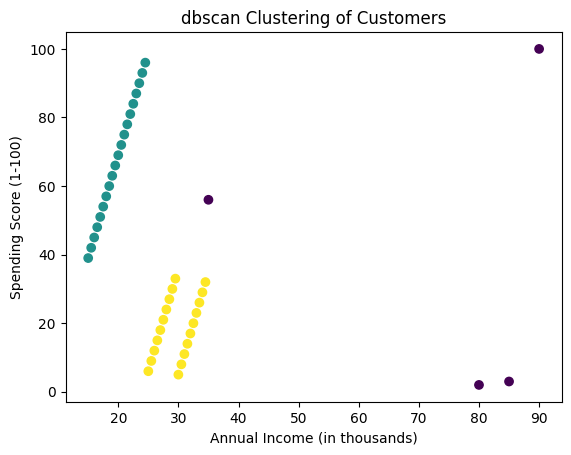

In [11]:
import matplotlib.pyplot as plt

# Plot the clusters
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='viridis')
plt.title('dbscan Clustering of Customers')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.show()

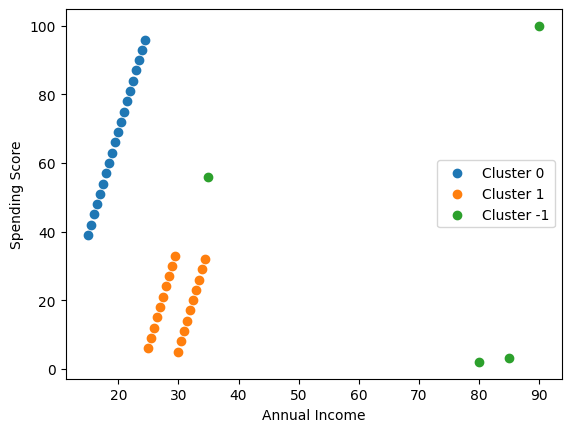

In [13]:
'''This gives Proper legend instead of color scale
Easier to explain in presentation/interview'''
for i in df['Cluster'].unique():
    subset = df[df['Cluster'] == i]
    plt.scatter(subset['AnnualIncome'], subset['SpendingScore'], label=f'Cluster {i}')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()



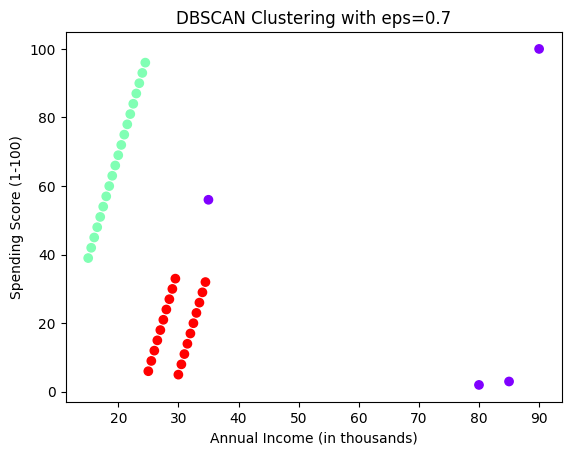

In [14]:
# Increase eps to 0.7 and refit DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(df_scaled)
df['Cluster'] = dbscan.labels_

# Plot the updated clusters
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='rainbow')
plt.title('DBSCAN Clustering with eps=0.7')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.show()

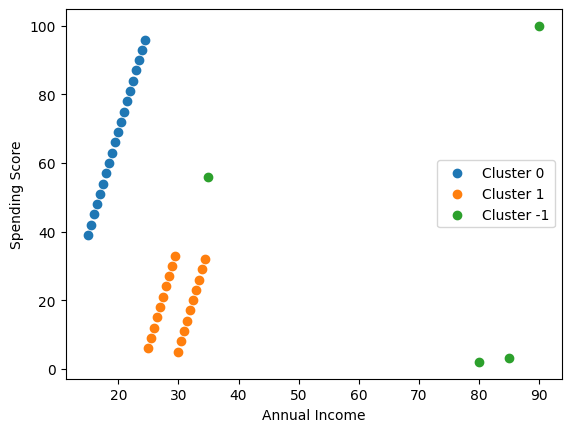

In [15]:
'''This gives Proper legend instead of color scale
Easier to explain in presentation/interview'''
for i in df['Cluster'].unique():
    subset = df[df['Cluster'] == i]
    plt.scatter(subset['AnnualIncome'], subset['SpendingScore'], label=f'Cluster {i}')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()
